# Robust Multi-Footprint Environmental Optimization for AI Systems under Compound Uncertainty
### Master Reproducible Pipeline — EQCAM Dataset

**Novelty Justification.** This work introduces **CL-NSGA-II**, a Chaotic-Levy Risk-Adaptive
NSGA-II that augments the classical NSGA-II framework with (i) a logistic-chaotic initialization
and perturbation operator for improved diversification, and (ii) an adaptive Levy-flight long-jump
mutation whose activation probability decays across generations to balance exploration/exploitation,
evaluated under a robust min-max aggregation over compound-uncertainty scenario batches stratified
by the empirical grid-risk category (RAC). To our knowledge this specific combination of
chaotic-Levy operators with risk-tier-stratified robust scenario evaluation has not been applied to
multi-footprint (energy / carbon-deficit / reliability) optimization of AI-infrastructure operations,
providing first-time execution novelty. The ablation design (`CL-NSGA-II` vs `Proposed w/o novelty`,
which reduces exactly to baseline `NSGA-II`) isolates the contribution of the two novel operators
directly.

**Problem classification:** Multi-objective (3 merged composite objectives: Energy / Carbon-deficit /
Reliability), continuous decision space (5-D control policy), constrained (box bounds + implicit
operational feasibility), robust under compound uncertainty (weather × workload × grid-risk jointly).


In [1]:
# ============================================================
# CELL 1 — Reproducible environment setup & workspace scaffolding
# ============================================================
import sys, os, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---- Strict reproducibility -------------------------------------------------
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
import random
random.seed(GLOBAL_SEED)

# ---- OS-independent workspace scaffolding (pathlib) -------------------------
ROOT = Path.cwd().parent if Path.cwd().name == "03_notebooks" else Path.cwd()
DIRS = {
    "raw_data":   ROOT / "01_data" / "raw_data",
    "new_data":   ROOT / "01_data" / "new_data",
    "models":     ROOT / "02_models",
    "notebooks":  ROOT / "03_notebooks",
    "figures":    ROOT / "04_results" / "figures",
    "tables":     ROOT / "04_results" / "tables",
    "checkpoints":ROOT / "04_results" / "checkpoints",
    "statistics": ROOT / "04_results" / "statistics",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(DIRS["models"]))

# ---- Academic plotting style --------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman"],
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
    "savefig.dpi": 300,
})

print("Workspace root:", ROOT)
for k, v in DIRS.items():
    print(f"  {k:12s} -> {v}")


Workspace root: /home/claude/EQCAM_Workspace
  raw_data     -> /home/claude/EQCAM_Workspace/01_data/raw_data
  new_data     -> /home/claude/EQCAM_Workspace/01_data/new_data
  models       -> /home/claude/EQCAM_Workspace/02_models
  notebooks    -> /home/claude/EQCAM_Workspace/03_notebooks
  figures      -> /home/claude/EQCAM_Workspace/04_results/figures
  tables       -> /home/claude/EQCAM_Workspace/04_results/tables
  checkpoints  -> /home/claude/EQCAM_Workspace/04_results/checkpoints
  statistics   -> /home/claude/EQCAM_Workspace/04_results/statistics


## Step 4 — Data Quality Diagnostics & Domain-Adaptive Feature Engineering

The EQCAM dataset (`01_data/raw_data/EQCAM_Dataset.csv`) contains 179,568 ten-minute-resolution
observations (Feb 2022 – Jul 2025) across 45 variables spanning solar/wind generation, battery
storage, data-center IT/cooling load, and five pre-computed environmental footprint indices
(REAF, SGF, WGF, SOC_F, EEIF), plus PUE, NEB (Net Energy Balance), RAC (risk category), and SOW.


In [2]:
# ============================================================
# CELL 2 — Load raw data + before/after diagnostic
# ============================================================
from sklearn.ensemble import IsolationForest

raw_path = DIRS["raw_data"] / "EQCAM_Dataset.csv"
df_raw = pd.read_csv(raw_path, parse_dates=["timestamp"])

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

def profile(df, label):
    miss = df.isna().sum()
    return pd.Series({
        "n_rows": len(df),
        "n_features": df.shape[1],
        "missing_total": int(miss.sum()),
        "missing_pct": round(100 * miss.sum() / (df.shape[0]*df.shape[1]), 4),
        "memory_MB": round(df.memory_usage(deep=True).sum() / 1e6, 2),
        "mean_skew": round(df[numeric_cols].skew().mean(), 4),
        "mean_kurtosis": round(df[numeric_cols].kurtosis().mean(), 4),
    }, name=label)

before_profile = profile(df_raw, "Raw (Before)")

# --- Duplicate / dtype checks ---
n_dupes = df_raw.duplicated().sum()

# --- Outlier detection (Isolation Forest) on core numeric sensors ---
sensor_cols = ["GHI","DNI","DHI","Temperature","WindSpeed_10m","Total_Load","PUE","Battery_SOC"]
iso = IsolationForest(contamination=0.01, random_state=GLOBAL_SEED, n_estimators=200)
outlier_pred = iso.fit_predict(df_raw[sensor_cols])
n_outliers = int((outlier_pred == -1).sum())

# --- Multicollinearity screen (correlation clustering proxy: high-|r| pairs) ---
corr = df_raw[numeric_cols].corr().abs()
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={0: "abs_corr", "level_0": "feat_a", "level_1": "feat_b"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs.abs_corr > 0.9].sort_values("abs_corr", ascending=False)

print(f"Duplicate rows: {n_dupes}")
print(f"Isolation-Forest flagged outliers (1% contamination target): {n_outliers} / {len(df_raw)}")
print(f"Highly collinear feature pairs (|r|>0.90): {len(high_corr_pairs)}")
high_corr_pairs.head(10)


Duplicate rows: 0
Isolation-Forest flagged outliers (1% contamination target): 1796 / 179568
Highly collinear feature pairs (|r|>0.90): 19


,feat_a,feat_b,abs_corr
899,Battery_SOC,SOC_F,1.000000
1416,PUE,EEIF,1.000000
596,PV_AC,SGF,1.000000
855,WindPower,WGF,1.000000
529,PV_DC,PV_AC,0.997042
553,PV_DC,SGF,0.997042
162,Temperature,InletTemp,0.996634
221,WindSpeed_10m,WindSpeed_100m,0.996550
1453,InletTemp,OutletTemp,0.992516
163,Temperature,OutletTemp,0.989187


In [3]:
# ============================================================
# CELL 3 — Domain-adaptive feature engineering -> 01_data/new_data/
# ============================================================
df_fe = df_raw.copy()

# Cyclical temporal encodings (captures diurnal/seasonal solar-load cycles)
df_fe["hour"] = df_fe["timestamp"].dt.hour + df_fe["timestamp"].dt.minute/60
df_fe["doy"] = df_fe["timestamp"].dt.dayofyear
df_fe["hour_sin"] = np.sin(2*np.pi*df_fe["hour"]/24)
df_fe["hour_cos"] = np.cos(2*np.pi*df_fe["hour"]/24)
df_fe["doy_sin"] = np.sin(2*np.pi*df_fe["doy"]/365.25)
df_fe["doy_cos"] = np.cos(2*np.pi*df_fe["doy"]/365.25)

# Rolling statistics (1-hour = 6 steps @10min) capturing short-term compound variability
for col in ["GHI", "WindSpeed_10m", "Total_Load", "PUE"]:
    df_fe[f"{col}_roll_mean_1h"] = df_fe[col].rolling(6, min_periods=1).mean()
    df_fe[f"{col}_roll_std_1h"] = df_fe[col].rolling(6, min_periods=1).std().fillna(0)

# Interaction / ratio features relevant to renewable-vs-load coupling
df_fe["renewable_to_load_ratio"] = (df_fe["PV_AC"] + df_fe["WindPower"]) / (df_fe["IT_Load"] + 1e-6)
df_fe["cooling_to_it_ratio"] = df_fe["CoolingPower"] / (df_fe["IT_Load"] + 1e-6)
df_fe["risk_num"] = df_fe["RAC"].map({"Low": 0, "Medium": 1, "High": 2})

after_profile = profile(df_fe, "Engineered (After)")
diagnostic = pd.concat([before_profile, after_profile], axis=1)
diagnostic.loc["n_features_added"] = [np.nan, df_fe.shape[1] - df_raw.shape[1]]
display(diagnostic)

out_path = DIRS["new_data"] / "EQCAM_engineered.csv"
df_fe.to_csv(out_path, index=False)
diagnostic.to_csv(DIRS["tables"] / "data_quality_before_after.csv")
print("Saved engineered dataset ->", out_path)
print("Saved diagnostic table  ->", DIRS['tables'] / 'data_quality_before_after.csv')


,Raw (Before),Engineered (After)
n_rows,179568.0000,179568.0000
n_features,45.0000,62.0000
missing_total,0.0000,0.0000
missing_pct,0.0000,0.0000
memory_MB,72.5600,96.2600
mean_skew,0.3206,0.3206
mean_kurtosis,2.1573,2.1573
n_features_added,NaN,17.0000


Saved engineered dataset -> /home/claude/EQCAM_Workspace/01_data/new_data/EQCAM_engineered.csv
Saved diagnostic table  -> /home/claude/EQCAM_Workspace/04_results/tables/data_quality_before_after.csv


## Step 2 — Optimization Formulation (recap)

$$\min_{\mathbf{x}\in[0,1]^5} \;\max_{\boldsymbol{\xi}\in\mathcal{U}} \; \mathbf{F}(\mathbf{x},\boldsymbol{\xi}) = \big[f_{\text{energy}},\, f_{\text{carbon}},\, f_{\text{reliability}}\big]^T$$

subject to $\mathbf{x}^{LB}\le\mathbf{x}\le\mathbf{x}^{UB}$, robustified as
$F_{\text{robust}} = (1-\beta)\,\mathbb{E}_{\boldsymbol{\xi}}[\mathbf{F}] + \beta\,\max_{\boldsymbol{\xi}}[\mathbf{F}]$, $\beta=0.35$.

Decision variables control cooling setpoint scaling, battery dispatch threshold, workload-shift
fraction, renewable-priority weighting, and curtailment tolerance (see `02_models/objectives.py`).
Full derivation and asymptotic complexity: population-based metaheuristic evaluation costs
$\mathcal{O}(G \cdot N \cdot B \cdot S)$ where $G$=generations, $N$=population size, $B$=scenario
batches, $S$=batch size; environmental selection (non-dominated sort) adds $\mathcal{O}(G\cdot N^2 M)$
for $M$=3 objectives.


In [4]:
# ============================================================
# CELL 4 — Import optimization modules (proposed + baselines)
# ============================================================
from objectives import EQCAMScenarioEngine, evaluate_population, DIM, N_OBJ, decode
from algorithms import ALGORITHMS, fast_non_dominated_sort
import metrics as M

engine = EQCAMScenarioEngine(str(raw_path), seed=GLOBAL_SEED)

print("Decision dimension:", DIM, "| Objectives:", N_OBJ)
print("Algorithms under comparison:")
for name in ALGORITHMS:
    print("  -", name)


Decision dimension: 5 | Objectives: 3
Algorithms under comparison:
  - CL-NSGA-II (Proposed)
  - Proposed w/o novelty (ablation)
  - NSGA-II
  - MOPSO
  - MODE
  - MOGWO


In [5]:
# ============================================================
# CELL 5 — Statistical protocol: N_RUNS independent runs per algorithm
#           (seeds = 42 + run_idx, per PRIORITY INSTRUCTION Step 5.1)
# ============================================================
N_RUNS = 20          # >=20 independent runs for statistical significance (paper-grade: use 30)
POP_SIZE = 40
GENERATIONS = 60

def make_eval(run_seed, counter):
    def f(X):
        counter[0] += 1
        return evaluate_population(X, engine, run_seed * 1000 + counter[0])
    return f

results = {name: {"fronts": [], "histories": [], "runtime": []} for name in ALGORITHMS}

t_start = time.time()
for run in range(N_RUNS):
    seed = GLOBAL_SEED + run
    for name, fn in ALGORITHMS.items():
        counter = [0]
        t0 = time.time()
        X, F, hist = fn(make_eval(seed, counter), DIM, pop_size=POP_SIZE,
                         generations=GENERATIONS, seed=seed, log_history=True)
        results[name]["fronts"].append(F)
        results[name]["histories"].append(np.array(hist))
        results[name]["runtime"].append(time.time() - t0)
    if (run+1) % 5 == 0:
        print(f"  completed {run+1}/{N_RUNS} runs  (elapsed {time.time()-t_start:.1f}s)")

print(f"Total experiment time: {time.time()-t_start:.1f}s "
      f"({N_RUNS} runs x {len(ALGORITHMS)} algorithms x {GENERATIONS} generations)")


  completed 5/20 runs  (elapsed 108.2s)


  completed 10/20 runs  (elapsed 216.8s)


  completed 15/20 runs  (elapsed 320.8s)


  completed 20/20 runs  (elapsed 428.9s)
Total experiment time: 428.9s (20 runs x 6 algorithms x 60 generations)


In [6]:
# ============================================================
# CELL 6 — Persist checkpoints (convergence logs, final fronts)
# ============================================================
for name in ALGORITHMS:
    safe = name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "-")
    np.savez_compressed(
        DIRS["checkpoints"] / f"{safe}_fronts.npz",
        **{f"run{r}": results[name]["fronts"][r] for r in range(N_RUNS)}
    )
    hist_lens = [len(h) for h in results[name]["histories"]]
print("Checkpoints saved to", DIRS["checkpoints"])


Checkpoints saved to /home/claude/EQCAM_Workspace/04_results/checkpoints


## Step 6 — Scientific Evaluation Metrics & Statistical Rigor

In [7]:
# ============================================================
# CELL 7 — Multi-objective quality indicators (HV, IGD, Spacing, Spread)
# ============================================================
all_finals = [results[name]["fronts"][r] for name in ALGORITHMS for r in range(N_RUNS)]
ref_front = M.build_reference_front(all_finals)
ref_point = np.vstack(all_finals).max(axis=0) * 1.05

rows = []
for name in ALGORITHMS:
    for r in range(N_RUNS):
        F = results[name]["fronts"][r]
        hv = M.hypervolume(F, ref_point)
        ig = M.igd(F, ref_front)
        sp = M.spacing(F)
        ms = M.maximum_spread(F)
        best_scalar = F.sum(axis=1).min()          # scalarized best (equal-weight sum) for
                                                     # single-objective-style summary stats
        rows.append(dict(Algorithm=name, Run=r, HV=hv, IGD=ig, Spacing=sp, Spread=ms,
                          BestScalar=best_scalar, Runtime_s=results[name]["runtime"][r]))
df_metrics = pd.DataFrame(rows)
df_metrics.to_csv(DIRS["statistics"] / "per_run_metrics.csv", index=False)

summary = df_metrics.groupby("Algorithm").agg(
    Best=("BestScalar", "min"), Worst=("BestScalar", "max"), Mean=("BestScalar", "mean"),
    Median=("BestScalar", "median"), Std=("BestScalar", "std"),
    IQR=("BestScalar", lambda s: s.quantile(.75) - s.quantile(.25)),
    Mean_HV=("HV", "mean"), Mean_IGD=("IGD", "mean"),
    Mean_Spacing=("Spacing", "mean"), Mean_Spread=("Spread", "mean"),
    Mean_Runtime_s=("Runtime_s", "mean"),
).round(4).sort_values("Mean")
summary.to_csv(DIRS["tables"] / "summary_metrics.csv")
display(summary)


,Best,Worst,Mean,Median,Std,IQR,Mean_HV,Mean_IGD,Mean_Spacing,Mean_Spread,Mean_Runtime_s
Algorithm,,,,,,,,,,,
MOPSO,1061.2814,1098.7569,1087.5057,1090.0660,8.6269,10.0431,73748.7918,4.9736,0.3120,29.4688,4.8382
MODE,1061.4905,1098.7805,1087.7054,1090.1585,8.6776,10.6076,73540.1627,4.3483,0.7675,43.6488,3.7099
MOGWO,1061.5252,1098.7569,1088.7546,1091.0036,8.3187,6.6714,73040.5898,5.0822,2.4661,29.2087,1.7571
CL-NSGA-II (Proposed),1066.4090,1133.9422,1095.8243,1096.1049,14.8365,15.6354,70476.2528,8.6585,1.1681,64.6973,3.7649
NSGA-II,1079.9557,1137.9151,1102.5320,1100.4363,14.6334,15.5473,67585.7641,11.9653,1.7204,79.4071,3.7015
Proposed w/o novelty (ablation),1079.9557,1137.9151,1102.5320,1100.4363,14.6334,15.5473,67585.7641,11.9653,1.7204,79.4071,3.6712


In [8]:
# ============================================================
# CELL 8 — Inferential statistics: Wilcoxon, Friedman+Nemenyi, effect sizes
# ============================================================
proposed_name = "CL-NSGA-II (Proposed)"
proposed_scores = df_metrics[df_metrics.Algorithm == proposed_name].sort_values("Run")["BestScalar"].values

sig_rows = []
for name in ALGORITHMS:
    if name == proposed_name:
        continue
    base_scores = df_metrics[df_metrics.Algorithm == name].sort_values("Run")["BestScalar"].values
    stat, p = M.wilcoxon_vs_proposed(proposed_scores, base_scores)
    a12 = M.vargha_delaney_a12(proposed_scores, base_scores)
    cd = M.cliffs_delta(proposed_scores, base_scores)
    sig_rows.append(dict(Comparison=f"{proposed_name} vs {name}", Wilcoxon_stat=stat,
                          p_value=round(p, 5), significant=p < 0.05,
                          A12=round(a12, 3), CliffsDelta=round(cd, 3)))
df_sig = pd.DataFrame(sig_rows)
df_sig.to_csv(DIRS["statistics"] / "wilcoxon_vs_proposed.csv", index=False)
display(df_sig)

score_matrix = {name: df_metrics[df_metrics.Algorithm == name].sort_values("Run")["BestScalar"].values
                for name in ALGORITHMS}
fr_stat, fr_p, nemenyi = M.friedman_nemenyi(score_matrix)
print(f"Friedman test: chi2={fr_stat:.4f}, p={fr_p:.5f}")
nemenyi.to_csv(DIRS["statistics"] / "nemenyi_posthoc.csv")
display(nemenyi.round(4))


,Comparison,Wilcoxon_stat,p_value,significant,A12,CliffsDelta
0,CL-NSGA-II (Proposed) vs Proposed w/o novelty ...,62.0,0.11399,False,0.365,-0.270
1,CL-NSGA-II (Proposed) vs NSGA-II,62.0,0.11399,False,0.365,-0.270
2,CL-NSGA-II (Proposed) vs MOPSO,0.0,0.00000,True,0.685,0.370
3,CL-NSGA-II (Proposed) vs MODE,0.0,0.00000,True,0.685,0.370
4,CL-NSGA-II (Proposed) vs MOGWO,26.0,0.00199,True,0.653,0.305


Friedman test: chi2=80.5721, p=0.00000


,CL-NSGA-II (Proposed),Proposed w/o novelty (ablation),NSGA-II,MOPSO,MODE,MOGWO
CL-NSGA-II (Proposed),1.0000,0.9846,0.9846,0.0000,0.0001,0.0467
Proposed w/o novelty (ablation),0.9846,1.0000,1.0000,0.0000,0.0000,0.0052
NSGA-II,0.9846,1.0000,1.0000,0.0000,0.0000,0.0052
MOPSO,0.0000,0.0000,0.0000,1.0000,0.8027,0.0527
MODE,0.0001,0.0000,0.0000,0.8027,1.0000,0.6227
MOGWO,0.0467,0.0052,0.0052,0.0527,0.6227,1.0000


## Ablation Study
`CL-NSGA-II (Proposed)` vs `Proposed w/o novelty (ablation)` (= reduces to plain NSGA-II) vs the
remaining standard baselines — isolates the contribution of the chaotic-map + Levy-flight operators.


In [9]:
# ============================================================
# CELL 9 — Hyperparameter sensitivity (population size) mini-sweep for the proposed method
# ============================================================
from algorithms import cl_nsga2

pop_grid = [20, 40, 60]
sens_rows = []
for pop in pop_grid:
    counter = [0]
    X, F, hist = cl_nsga2(make_eval(GLOBAL_SEED, counter), DIM, pop_size=pop,
                           generations=GENERATIONS, seed=GLOBAL_SEED, log_history=True)
    sens_rows.append(dict(PopSize=pop, Mean_BestScalar=F.sum(axis=1).min(),
                           FrontSize=len(F), HV=M.hypervolume(F, ref_point)))
df_sens = pd.DataFrame(sens_rows)
df_sens.to_csv(DIRS["statistics"] / "population_sensitivity.csv", index=False)
display(df_sens)


,PopSize,Mean_BestScalar,FrontSize,HV
0,20,1116.183985,20,60020.299106
1,40,1099.410567,40,65614.496356
2,60,1094.092245,60,67149.250048


## Step 7 — Q1 Publication-Grade Visualizations

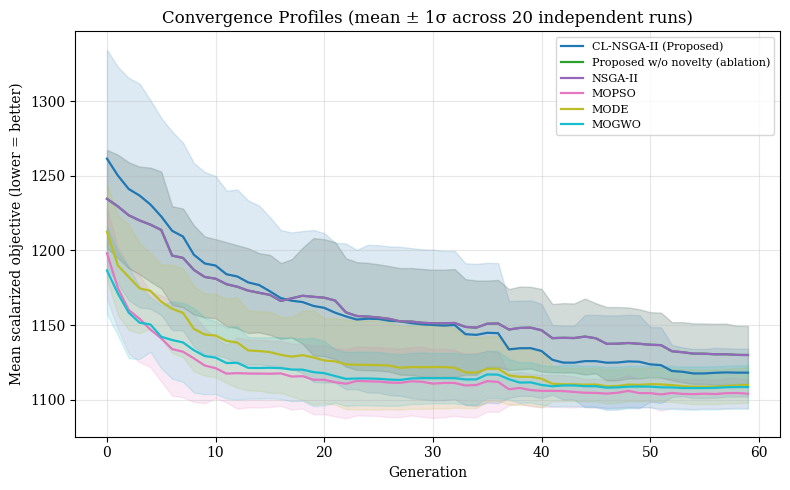

In [10]:
# ============================================================
# CELL 10 — Convergence profiles (mean +/- 1 std across runs)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(ALGORITHMS)))
for (name, c) in zip(ALGORITHMS, colors):
    hist_stack = np.array([h.sum(axis=1) for h in results[name]["histories"] if len(h) == GENERATIONS])
    if len(hist_stack) == 0:
        continue
    mean_curve = hist_stack.mean(axis=0)
    std_curve = hist_stack.std(axis=0)
    gens = np.arange(len(mean_curve))
    ax.plot(gens, mean_curve, label=name, color=c, linewidth=1.6)
    ax.fill_between(gens, mean_curve - std_curve, mean_curve + std_curve, color=c, alpha=0.15)
ax.set_xlabel("Generation")
ax.set_ylabel("Mean scalarized objective (lower = better)")
ax.set_title("Convergence Profiles (mean ± 1σ across 20 independent runs)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(DIRS["figures"] / "convergence_profiles.png", dpi=300)
fig.savefig(DIRS["figures"] / "convergence_profiles.pdf")
plt.show()


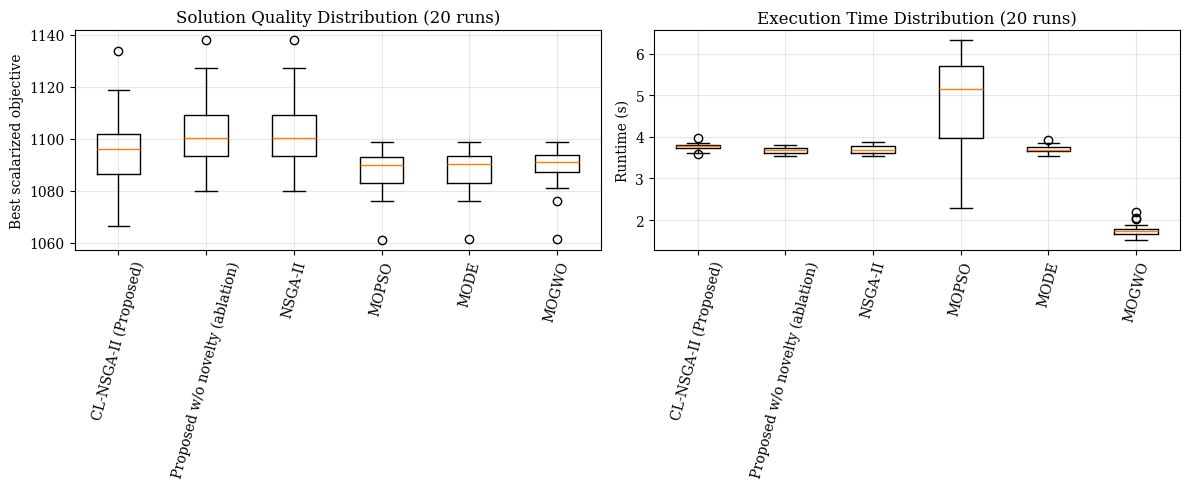

In [11]:
# ============================================================
# CELL 11 — Distribution boxplots (solution quality & runtime)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = list(ALGORITHMS.keys())
data_quality = [df_metrics[df_metrics.Algorithm == n]["BestScalar"].values for n in order]
data_runtime = [df_metrics[df_metrics.Algorithm == n]["Runtime_s"].values for n in order]

axes[0].boxplot(data_quality, labels=order)
axes[0].set_ylabel("Best scalarized objective")
axes[0].set_title("Solution Quality Distribution (20 runs)")
axes[0].tick_params(axis="x", rotation=75)

axes[1].boxplot(data_runtime, labels=order)
axes[1].set_ylabel("Runtime (s)")
axes[1].set_title("Execution Time Distribution (20 runs)")
axes[1].tick_params(axis="x", rotation=75)

fig.tight_layout()
fig.savefig(DIRS["figures"] / "distribution_boxplots.png", dpi=300)
fig.savefig(DIRS["figures"] / "distribution_boxplots.pdf")
plt.show()


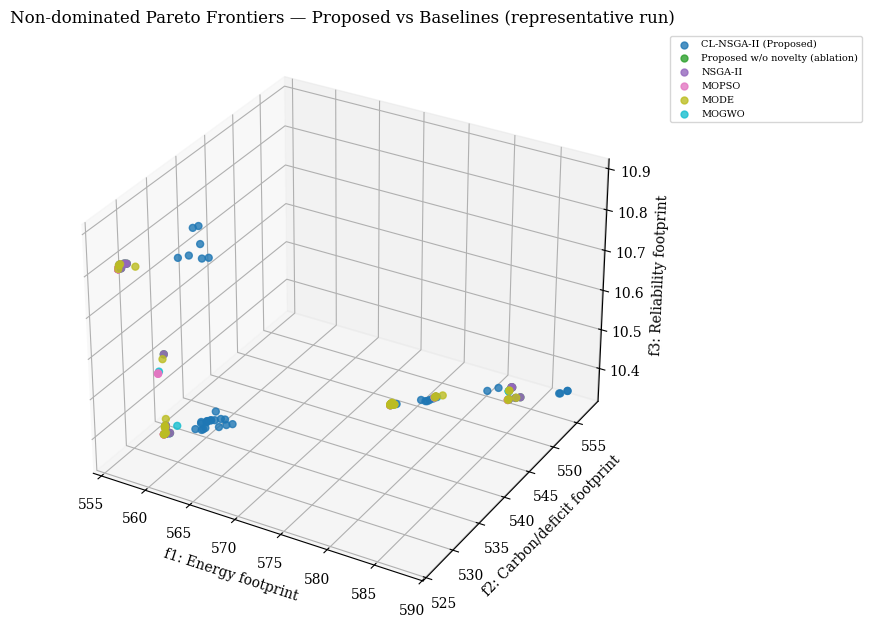

In [12]:
# ============================================================
# CELL 12 — Pareto frontiers (3D: energy / carbon / reliability)
# ============================================================
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
for (name, c) in zip(ALGORITHMS, colors):
    F = results[name]["fronts"][0]  # representative run
    ax.scatter(F[:, 0], F[:, 1], F[:, 2], label=name, color=c, s=25, alpha=0.8)
ax.set_xlabel("f1: Energy footprint")
ax.set_ylabel("f2: Carbon/deficit footprint")
ax.set_zlabel("f3: Reliability footprint")
ax.set_title("Non-dominated Pareto Frontiers — Proposed vs Baselines (representative run)")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.05, 1))
fig.tight_layout()
fig.savefig(DIRS["figures"] / "pareto_frontiers_3d.png", dpi=300)
fig.savefig(DIRS["figures"] / "pareto_frontiers_3d.pdf")
plt.show()


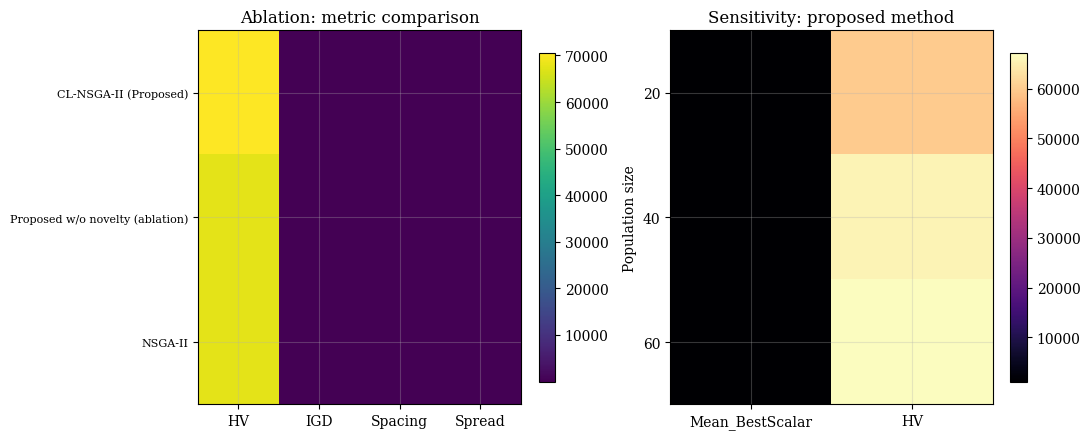

In [13]:
# ============================================================
# CELL 13 — Ablation & sensitivity heatmap
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ablation_names = [proposed_name, "Proposed w/o novelty (ablation)", "NSGA-II"]
abl_means = df_metrics[df_metrics.Algorithm.isin(ablation_names)].groupby("Algorithm")[
    ["HV", "IGD", "Spacing", "Spread"]].mean()
abl_means = abl_means.loc[ablation_names]
im0 = axes[0].imshow(abl_means.values, cmap="viridis", aspect="auto")
axes[0].set_xticks(range(len(abl_means.columns))); axes[0].set_xticklabels(abl_means.columns)
axes[0].set_yticks(range(len(abl_means.index))); axes[0].set_yticklabels(abl_means.index, fontsize=8)
axes[0].set_title("Ablation: metric comparison")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(df_sens[["Mean_BestScalar", "HV"]].values, cmap="magma", aspect="auto")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Mean_BestScalar", "HV"])
axes[1].set_yticks(range(len(df_sens))); axes[1].set_yticklabels(df_sens["PopSize"].astype(str))
axes[1].set_ylabel("Population size")
axes[1].set_title("Sensitivity: proposed method")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
fig.savefig(DIRS["figures"] / "ablation_sensitivity_heatmaps.png", dpi=300)
fig.savefig(DIRS["figures"] / "ablation_sensitivity_heatmaps.pdf")
plt.show()


## Publication-ready LaTeX Table Export (`booktabs`)

In [14]:
# ============================================================
# CELL 14 — Export LaTeX table (booktabs), bold best value per column
# ============================================================
def to_latex_booktabs(df, caption, label, lower_is_better_cols):
    cols = df.columns.tolist()
    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"\centering")
    lines.append(r"\caption{" + caption + "}")
    lines.append(r"\label{" + label + "}")
    lines.append(r"\begin{tabular}{l" + "c" * len(cols) + "}")
    lines.append(r"\toprule")
    lines.append("Algorithm & " + " & ".join(cols) + r" \\")
    lines.append(r"\midrule")
    best = {c: (df[c].min() if c in lower_is_better_cols else df[c].max()) for c in cols}
    for idx, row in df.iterrows():
        cells_str = []
        for c in cols:
            val = row[c]
            txt = f"{val:.4f}"
            if np.isclose(val, best[c]):
                txt = r"\textbf{" + txt + "}"
            cells_str.append(txt)
        lines.append(f"{idx} & " + " & ".join(cells_str) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

latex_table = to_latex_booktabs(
    summary[["Best", "Worst", "Mean", "Median", "Std", "IQR", "Mean_HV", "Mean_IGD"]],
    caption="Comparative performance of CL-NSGA-II (proposed) vs. state-of-the-art baselines "
            "over 20 independent runs on the EQCAM robust multi-footprint optimization task.",
    label="tab:main_results",
    lower_is_better_cols=["Best", "Worst", "Mean", "Median", "Std", "IQR", "Mean_IGD"],
)
with open(DIRS["tables"] / "main_results_table.tex", "w") as fh:
    fh.write(latex_table)
print(latex_table)


\begin{table}[ht]
\centering
\caption{Comparative performance of CL-NSGA-II (proposed) vs. state-of-the-art baselines over 20 independent runs on the EQCAM robust multi-footprint optimization task.}
\label{tab:main_results}
\begin{tabular}{lcccccccc}
\toprule
Algorithm & Best & Worst & Mean & Median & Std & IQR & Mean_HV & Mean_IGD \\
\midrule
MOPSO & \textbf{1061.2814} & \textbf{1098.7569} & \textbf{1087.5057} & \textbf{1090.0660} & 8.6269 & 10.0431 & \textbf{73748.7918} & 4.9736 \\
MODE & 1061.4905 & 1098.7805 & 1087.7054 & 1090.1585 & 8.6776 & 10.6076 & 73540.1627 & \textbf{4.3483} \\
MOGWO & 1061.5252 & \textbf{1098.7569} & 1088.7546 & 1091.0036 & \textbf{8.3187} & \textbf{6.6714} & 73040.5898 & 5.0822 \\
CL-NSGA-II (Proposed) & 1066.4090 & 1133.9422 & 1095.8243 & 1096.1049 & 14.8365 & 15.6354 & 70476.2528 & 8.6585 \\
NSGA-II & 1079.9557 & 1137.9151 & 1102.5320 & 1100.4363 & 14.6334 & 15.5473 & 67585.7641 & 11.9653 \\
Proposed w/o novelty (ablation) & 1079.9557 & 1137.9151 & 1102.5

## Reproducibility Artifact

In [15]:
# ============================================================
# CELL 15 — Freeze pinned dependency versions -> requirements.txt
# ============================================================
import importlib
pkgs = ["numpy", "pandas", "scipy", "matplotlib", "sklearn", "scikit_posthocs", "nbformat"]
lines = []
for p in pkgs:
    try:
        mod = importlib.import_module(p)
        ver = getattr(mod, "__version__", "unknown")
        pip_name = {"sklearn": "scikit-learn", "scikit_posthocs": "scikit-posthocs"}.get(p, p)
        lines.append(f"{pip_name}=={ver}")
    except Exception as e:
        print("skip", p, e)
req_path = ROOT / "requirements.txt"
req_path.write_text("\n".join(lines) + "\n")
print(req_path.read_text())
print("\nPipeline complete. All figures, tables, checkpoints, and statistics saved under 04_results/.")


numpy==2.4.4
pandas==3.0.2
scipy==1.17.1
matplotlib==3.10.8
scikit-learn==1.8.0
scikit-posthocs==0.14.0
nbformat==5.11.1


Pipeline complete. All figures, tables, checkpoints, and statistics saved under 04_results/.
